In [215]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

pd.set_option('display.precision', 3)

# Extra imports
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import graphviz

from sklearn.tree import export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,GradientBoostingClassifier,StackingClassifier,ExtraTreesClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.naive_bayes import GaussianNB

from time import time
from datetime import timedelta

import seaborn as sns
from matplotlib import pyplot as plt

In [216]:
import warnings
warnings.filterwarnings('ignore')

In [217]:
np.random.seed(6046)

In [218]:
def confusion(true, pred):
    """
    Function for pretty printing confusion matrices
    """
    pred = pd.Series(pred)
    true = pd.Series(true)
    
    true.name = 'target'
    pred.name = 'predicted'
    cm = pd.crosstab(true.reset_index(drop=True), pred.reset_index(drop=True))
    cm = cm[cm.index]
    return cm

# Reading CSV

In [219]:
ILDS = read_csv("train_features_ILDS.csv", delimiter=',', header=None)

ILDS.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR']
ILDS['target'] = read_csv("train_labels_ILDS.csv", delimiter=',', header=None)

ILDS.shape

(463, 11)

In [220]:
ILDS.describe(include='all')

,Age,Female,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,target
count,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000
mean,44.881,0.242,3.279,1.446,279.866,75.844,97.607,6.422,3.110,0.943,0.285
std,16.309,0.429,6.115,2.675,211.283,169.290,212.114,1.052,0.793,0.318,0.452
min,4.000,0.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300,0.000
25%,33.000,0.000,0.800,0.200,176.000,23.000,25.000,5.700,2.500,0.700,0.000
50%,45.000,0.000,1.000,0.300,208.000,34.000,41.000,6.500,3.100,0.920,0.000
75%,57.500,0.000,2.700,1.300,291.000,60.000,83.500,7.100,3.700,1.100,1.000
max,90.000,1.000,75.000,18.300,1630.000,2000.000,2946.000,9.500,5.500,2.800,1.000


In [221]:
X_train, X_test, y_train, y_test = train_test_split(ILDS.loc[:,:'AR'], ILDS.loc[:,'target'],  
                                                    test_size=0.2, stratify=ILDS.loc[:,'target'], random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

X_train.shape, X_val.shape, X_test.shape


((277, 10), (93, 10), (93, 10))

# Metrics

In [222]:
def compute_metrics(y_true,y_pred):
    accuracy = accuracy_score(y_true,y_pred)
    f1_score_1 = f1_score(y_true,y_pred,average='binary',pos_label=1)
    f1_score_0 = f1_score(y_true,y_pred,average='binary',pos_label=0)
    f1_score_macro = f1_score(y_true,y_pred,average='macro')
    return [accuracy,f1_score_1,f1_score_0,f1_score_macro]
    
    

results = pd.DataFrame(columns=['Accuracy', 'F1-score (class 1)', 'F1-score (class 0)', 'F1-score (macro avg)'])

In [223]:
model_tree = DecisionTreeClassifier().fit(X_train, y_train)

In [224]:
y_pred = model_tree.predict(X_val)

results.loc['DT-default',:] = compute_metrics(y_val, y_pred)

confusion(y_val, y_pred)

predicted,0,1
target,,
0,54,13
1,11,15


In [225]:
print(classification_report(y_val, y_pred, target_names=['no', 'yes'],))

results

              precision    recall  f1-score   support

          no       0.83      0.81      0.82        67
         yes       0.54      0.58      0.56        26

    accuracy                           0.74        93
   macro avg       0.68      0.69      0.69        93
weighted avg       0.75      0.74      0.74        93



,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
DT-default,0.742,0.556,0.818,0.687


In [226]:
y_pred_train = model_tree.predict(X_train)

confusion(y_train,y_pred_train)

print(classification_report(y_train, y_pred_train, target_names=['no', 'yes'],))

              precision    recall  f1-score   support

          no       1.00      1.00      1.00       198
         yes       1.00      1.00      1.00        79

    accuracy                           1.00       277
   macro avg       1.00      1.00      1.00       277
weighted avg       1.00      1.00      1.00       277



In [227]:
print('Tree depht: {}\nNodes: {}'.format(model_tree.tree_.max_depth, model_tree.tree_.node_count))

Tree depht: 12
Nodes: 111


In [228]:
criterion = ['gini', 'entropy']

max_dephts = [None, 5, 10, 15, 20]
min_samples_split = [1, 2, 3, 4, 5]
min_samples_leaf = [1, 2, 3, 4, 5]
max_features = ['auto', 'sqrt', 'log2', None]

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

init_time = time()
model_tree = DecisionTreeClassifier()

f1_class_0_scorer = make_scorer(f1_score, pos_label=0)
f1_class_1_scorer = make_scorer(f1_score, pos_label=1)

scoring_dict = {
    'f1_mac': 'f1_macro',
    'f1_class_0': f1_class_0_scorer,
    'f1_class_1': f1_class_1_scorer,
    'acc': 'accuracy'
}

trc = GridSearchCV(estimator=model_tree,
                   scoring=scoring_dict,
                   param_grid={
                       'criterion': criterion,
                       'max_depth': max_dephts,
                       'min_samples_split': min_samples_split,
                       'min_samples_leaf': min_samples_leaf,
                       'max_features': max_features
                   },
                   cv=5,
                   return_train_score=False,
                   refit='f1_mac')

model_5CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

0:00:16.674575


In [229]:
scoring_cols = [
    'param_criterion', 'param_max_depth', 'param_max_features',
    'param_min_samples_leaf', 'param_min_samples_split', 'mean_test_f1_mac',
    'mean_test_f1_class_0', 'mean_test_f1_class_1', 'mean_test_acc'
]

pd.DataFrame(model_5CV.cv_results_).sort_values(by='mean_test_f1_mac', ascending=False)[scoring_cols].head()

,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,mean_test_f1_mac,mean_test_f1_class_0,mean_test_f1_class_1,mean_test_acc
872,entropy,15,log2,5,3,0.643,0.807,0.478,0.718
241,gini,10,sqrt,4,2,0.640,0.799,0.481,0.711
473,gini,20,log2,5,4,0.637,0.808,0.466,0.718
258,gini,10,log2,2,4,0.635,0.779,0.492,0.693
962,entropy,20,log2,3,3,0.630,0.809,0.451,0.718


In [230]:
best_params = model_5CV.best_params_
best_params

{'criterion': 'entropy',
 'max_depth': 15,
 'max_features': 'log2',
 'min_samples_leaf': 5,
 'min_samples_split': 3}

In [231]:
y_pred = model_5CV.predict(X_val)

results.loc['DT-best',:] = compute_metrics(y_val, y_pred)

confusion(y_val,y_pred)
results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
DT-default,0.742,0.556,0.818,0.687
DT-best,0.742,0.4,0.836,0.618


# Random Forest

In [232]:
model_rf1 = RandomForestClassifier(oob_score=True).fit(X_train, y_train)

pred = model_rf1.predict(X_train)

confusion(y_train,pred)

print(classification_report(y_train, pred, target_names=['no', 'yes'],))

print('OOB accuracy=', model_rf1.oob_score_)

              precision    recall  f1-score   support

          no       1.00      1.00      1.00       198
         yes       1.00      1.00      1.00        79

    accuracy                           1.00       277
   macro avg       1.00      1.00      1.00       277
weighted avg       1.00      1.00      1.00       277

OOB accuracy= 0.6895306859205776


In [233]:
y_pred = model_rf1.predict(X_val)
print('Validation Accuracy:{}'.format(model_rf1.score(X_val,y_val)))
results.loc['RF-default',:] = compute_metrics(y_val,y_pred)
confusion(y_val,y_pred)

Validation Accuracy:0.7849462365591398


predicted,0,1
target,,
0,63,4
1,16,10


In [234]:
results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
DT-best,0.742,0.4,0.836,0.618


In [235]:
model_rf2 = RandomForestClassifier(n_estimators=100, 
                                   oob_score=True, 
                                   class_weight='balanced').fit(X_train, y_train)

pred = model_rf2.predict(X_train)

confusion(y_train, pred)

print(classification_report(y_train,pred,target_names=['no', 'yes'],))

print('OOB accuracy=', model_rf2.oob_score_)

              precision    recall  f1-score   support

          no       1.00      1.00      1.00       198
         yes       1.00      1.00      1.00        79

    accuracy                           1.00       277
   macro avg       1.00      1.00      1.00       277
weighted avg       1.00      1.00      1.00       277

OOB accuracy= 0.6714801444043321


In [236]:
y_pred = model_rf2.predict(X_val)

results.loc['RF-balance',:] = compute_metrics(y_val,y_pred)

confusion(y_val,y_pred)

predicted,0,1
target,,
0,61,6
1,18,8


In [237]:
results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


In [238]:
init_time = time()

rf_model = RandomForestClassifier()

ntrees = [200,None]
max_depth = [100,None]
min_samples_split = [4,6]
min_samples_leaf = [4,6]
balance = [None, 'balanced', 'balanced_subsample']

trc = GridSearchCV(estimator=rf_model,
                   scoring=scoring_dict,
                   param_grid={
                       'n_estimators': ntrees,
                       'max_depth':max_depth,
                       'min_samples_split':min_samples_split,
                       'min_samples_leaf':min_samples_leaf, 
                       'class_weight':balance
                   },
                   cv=5,
                   return_train_score=False,
                   refit=False,
                   n_jobs=-1)

model_5CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

0:00:05.963960


In [239]:
scoring_cols = [
    'param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split',
    'mean_test_f1_mac', 'mean_test_f1_class_0', 'mean_test_f1_class_1',
    'mean_test_acc'
]
pd.DataFrame(model_5CV.cv_results_).sort_values(
    by='mean_test_f1_mac', ascending=False)[scoring_cols].head()

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_f1_mac,mean_test_f1_class_0,mean_test_f1_class_1,mean_test_acc
30,None,6,6,0.655,0.768,0.542,0.693
22,100,6,6,0.654,0.763,0.545,0.689
20,100,6,4,0.652,0.764,0.539,0.689
44,None,6,4,0.652,0.765,0.539,0.689
36,100,6,4,0.649,0.767,0.530,0.689


In [240]:
best_params = pd.DataFrame(model_5CV.cv_results_).sort_values(by='mean_test_f1_mac',ascending=False)[['params']].iloc[0,0]
best_params

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 6,
 'min_samples_split': 6,
 'n_estimators': 200}

In [241]:
rf_model_tuned = RandomForestClassifier(**best_params)
rf_model_tuned.fit(X_train, y_train)

y_pred = rf_model_tuned.predict(X_val)

results.loc['RF-best', :] = compute_metrics(y_val, y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
RF-best,0.667,0.551,0.735,0.643
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


In [242]:
confusion(y_val, y_pred)

predicted,0,1
target,,
0,43,24
1,7,19


# Extra trees

In [243]:
extra_trees = ExtraTreesClassifier()
extra_trees.fit(X_train,y_train)

y_pred = extra_trees.predict(X_val)

results.loc['extra_trees',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees,0.774,0.553,0.849,0.701
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
RF-best,0.667,0.551,0.735,0.643
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


In [244]:
init_time = time()

rf_model = ExtraTreesClassifier(class_weight='balanced')

ntrees = [150, None]
max_depth = [100, None]
min_samples_split = [4, 6]
min_samples_leaf = [2, 4]
balance = [None, 'balanced', 'balanced_subsample']

trc = GridSearchCV(estimator=rf_model,
                   scoring=scoring_dict,
                   param_grid={
                       'n_estimators': ntrees,
                       'max_depth': max_depth,
                       'min_samples_split': min_samples_split,
                       'min_samples_leaf': min_samples_leaf,
                       'class_weight': balance
                   },
                   cv=5,
                   return_train_score=True,
                   refit=False,
                   n_jobs=-1)

model_5CV = trc.fit(X_train, y_train)
print(timedelta(seconds=(time() - init_time)))

0:00:03.455926


In [245]:
pd.DataFrame(model_5CV.cv_results_).sort_values(by='mean_test_f1_mac',ascending=False)[scoring_cols].head()

,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_f1_mac,mean_test_f1_class_0,mean_test_f1_class_1,mean_test_acc
30,None,4,6,0.684,0.763,0.606,0.704
22,100,4,6,0.677,0.756,0.597,0.696
46,None,4,6,0.671,0.755,0.586,0.693
20,100,4,4,0.669,0.757,0.582,0.693
28,None,4,4,0.669,0.750,0.587,0.689


In [246]:
best_params = pd.DataFrame(model_5CV.cv_results_).sort_values(by='mean_test_f1_mac',ascending=False)[['params']].iloc[0,0]
best_params

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 6,
 'n_estimators': 150}

In [247]:
extra_trees_best = ExtraTreesClassifier(**best_params)
extra_trees_best.fit(X_train,y_train)

y_pred = extra_trees_best.predict(X_val)

results.loc['extra_trees-best',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees,0.774,0.553,0.849,0.701
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
RF-best,0.667,0.551,0.735,0.643
extra_trees-best,0.656,0.568,0.714,0.641
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


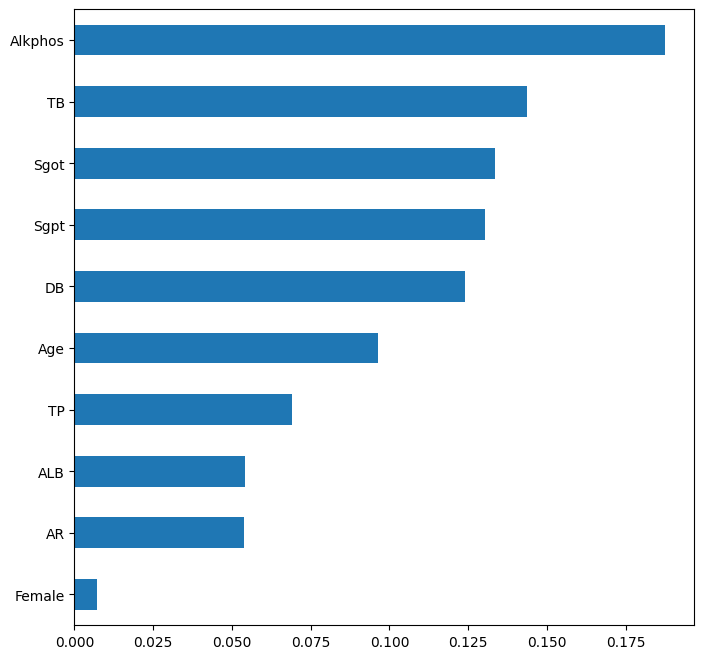

In [248]:
var_imp = pd.DataFrame({'importance': rf_model_tuned.feature_importances_},
                       index=X_train.columns)

var_imp.sort_values(by='importance').plot.barh(figsize=(8,8),
                                               legend=False);

# Ensembles

In [249]:
gauss_nb = GaussianNB()
gauss_nb.fit(X_train,y_train)

y_pred = gauss_nb.predict(X_val)

results.loc['GaussianNB-default',:] = compute_metrics(y_val,y_pred)

results.sort_values(by='F1-score (macro avg)', ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees,0.774,0.553,0.849,0.701
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
RF-best,0.667,0.551,0.735,0.643
extra_trees-best,0.656,0.568,0.714,0.641
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618
GaussianNB-default,0.452,0.495,0.4,0.448


In [250]:
voting_hard = VotingClassifier([('dt', model_tree), ('rf', model_rf1),
                                ('gnb', gauss_nb),('extratrees',extra_trees)])
voting_hard.fit(X_train, y_train)

y_pred = voting_hard.predict(X_val)

results.loc['voting_hard', :] = compute_metrics(y_val, y_pred)

results.loc[['DT-default','GaussianNB-default','RF-default','extra_trees','voting_hard'],:].sort_values(
    by='F1-score (class 1)',ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
voting_hard,0.806,0.591,0.873,0.732
DT-default,0.742,0.556,0.818,0.687
extra_trees,0.774,0.553,0.849,0.701
RF-default,0.785,0.5,0.863,0.682
GaussianNB-default,0.452,0.495,0.4,0.448


In [251]:
voting_soft = VotingClassifier([('dt', model_tree), ('rf', model_rf1),
                                ('gnb', gauss_nb),('extratrees',extra_trees)],voting='soft')
voting_soft.fit(X_train, y_train)

y_pred = voting_soft.predict(X_val)

results.loc['voting_soft', :] = compute_metrics(y_val, y_pred)

results.loc[['DT-default','GaussianNB-default','RF-default','extra_trees','voting_hard','voting_soft'],:].sort_values(
    by='F1-score (macro avg)',ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
voting_hard,0.806,0.591,0.873,0.732
extra_trees,0.774,0.553,0.849,0.701
voting_soft,0.72,0.618,0.78,0.699
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
GaussianNB-default,0.452,0.495,0.4,0.448


In [252]:
voting_best = VotingClassifier([('rf', rf_model_tuned),
                                ('extratrees',extra_trees_best)],voting='hard')
voting_best.fit(X_train, y_train)

y_pred = voting_best.predict(X_val)

results.loc['voting_best', :] = compute_metrics(y_val, y_pred)

results.loc[:].sort_values(by='F1-score (macro avg)',ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
voting_hard,0.806,0.591,0.873,0.732
extra_trees,0.774,0.553,0.849,0.701
voting_soft,0.72,0.618,0.78,0.699
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
voting_best,0.677,0.545,0.75,0.648
RF-best,0.667,0.551,0.735,0.643
extra_trees-best,0.656,0.568,0.714,0.641
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


# Stacking Classifier

In [253]:
stacky = StackingClassifier(
    estimators=[('rf', rf_model_tuned), ('extratrees', extra_trees_best)],
    final_estimator=GradientBoostingClassifier())

stacky.fit(X_train, y_train)

y_pred = stacky.predict(X_val)

results.loc['stackyn-clf', :] = compute_metrics(y_val, y_pred)
results.loc[['RF-best','extra_trees-best','stackyn-clf'],:].sort_values(by='F1-score (class 1)',ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
extra_trees-best,0.656,0.568,0.714,0.641
RF-best,0.667,0.551,0.735,0.643
stackyn-clf,0.71,0.426,0.806,0.616


In [254]:
results.sort_values(by='F1-score (macro avg)',ascending=False)

,Accuracy,F1-score (class 1),F1-score (class 0),F1-score (macro avg)
voting_hard,0.806,0.591,0.873,0.732
extra_trees,0.774,0.553,0.849,0.701
voting_soft,0.72,0.618,0.78,0.699
DT-default,0.742,0.556,0.818,0.687
RF-default,0.785,0.5,0.863,0.682
voting_best,0.677,0.545,0.75,0.648
RF-best,0.667,0.551,0.735,0.643
extra_trees-best,0.656,0.568,0.714,0.641
DT-best,0.742,0.4,0.836,0.618
RF-balance,0.742,0.4,0.836,0.618


In [255]:
y_pred = rf_model_tuned.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.64      0.71        66
           1       0.40      0.59      0.48        27

    accuracy                           0.62        93
   macro avg       0.60      0.61      0.59        93
weighted avg       0.68      0.62      0.64        93



# F1 Check

In [256]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
import numpy as np

def compute_metrics (y_real, y_pred) -> list[float]:
    F1_macro = f1_score(y_real, y_pred, average = "macro")
    recall = recall_score(y_real, y_pred, average = "macro")
    prec = precision_score(y_real, y_pred, average = "macro")
    acc = accuracy_score(y_real, y_pred)
    return [F1_macro, recall, prec, acc]

def confusion (y_real, y_pred) -> None:
    TP = sum(np.logical_and(y_real == y_pred, y_real == 1))
    TN = sum(np.logical_and(y_real == y_pred, y_real == 0))
    FP = sum(np.logical_and(y_real != y_pred, y_real == 0))
    FN = sum(np.logical_and(y_real != y_pred, y_real == 1))
    print("\t\tPredicted")
    print("\t\t+1\t0")
    print(f"Real\t+1\t{TP}\t{FN}")
    print(f"\t0\t{FP}\t{TN}")
    print(f"Accuracy: {((TP + TN) / y_real.shape[0] * 100):.2f}%".format())

metrics_df = pd.DataFrame(columns = ["F1 Macro", "Recall", "Precision", "Accuracy"])

In [261]:
test_y = pd.read_csv("test_y.csv").iloc[:, 1]

ILDS_test = read_csv("test_data_ILDS.csv", delimiter=',', header = None)

ILDS_test.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR']

In [270]:
from sklearn.ensemble import RandomForestClassifier

labels_rf = pd.DataFrame(columns = ['ID', 'Label'])
labels_rf['Label'] = pd.DataFrame(voting_hard.predict(ILDS_test))
labels_rf['ID'] = labels_rf.index + 1

confusion(test_y, labels_rf['Label'])

compute_metrics(test_y, labels_rf['Label'])

		Predicted
		+1	0
Real	+1	13	20
	0	10	73
Accuracy: 74.14%


[0.6469155844155845,
 0.6367287331142752,
 0.6750818139317438,
 0.7413793103448276]

# Test

In [259]:
ILDS_test = read_csv("test_data_ILDS.csv", delimiter=',', header = None)

ILDS_test.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR']

X_test = ILDS_test.loc[:,:'AR']

ILDS_test['Label'] = voting_hard.predict(X_test)

ILDS_test.index = ILDS_test.index + 1
ILDS_test.index.name = 'ID'

ILDS_test['Label'].to_csv('voting_hard.csv', index=True)